# Tourism & Hospitality Conversational AI Bot
### Industry-Specific Conversational AI — Capstone Project
**Author: Santosh Kumar**

This notebook is built to be **restart-safe**: all data is saved to Google Drive the
first time you upload it, and every later cell reads from Drive — so if Colab
disconnects or you restart the session, you do NOT need to re-upload anything.

**Run order:** Run cells top to bottom, in order, the first time. If you restart the
session later, just run all cells again — uploaded files will be found in Drive
automatically and won't ask again.

**Pipeline:**
1. Setup & Google Drive mount
2. Upload data (one-time) — Q&A dataset, Hotel Bookings, and the 4 Kaggle tourism-destination files
3. Preprocessing & tokenization
4. Fine-tuning DistilGPT2 (25 epochs)
5. Evaluation (loss curves, perplexity)
6. Testing the bot + Gradio demo
7. Supporting EDA — Hotel Bookings + Tourism Destinations + recommender


**Github Link : ** https://github.com/sant8ntl-max/Reserch-_in_Tourism-hospitality_ChatBot

# **Research paper * #*: https://docs.google.com/document/d/1pOlJnjoo9XNHLdkOzQCYa5RGXdfj0V0gKCBUPDmIKpQ/edit?usp=sharing

## 1. Setup & Installation

In [ ]:

!pip install -q -U "transformers>=4.41" "tokenizers>=0.19" datasets accelerate evaluate gradio scikit-learn
print("setup Installed sucessfully")


## 2. Google Drive Setup (persistent storage)
All required files are saved to `PROJECT_DIR` in your Drive the first time. On every
future run, this cell automatically detects which files already exist and only asks
you to upload the ones that are missing.

In [ ]:
import os, shutil, re
from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/tourism_bot_project'
os.makedirs(PROJECT_DIR, exist_ok=True)

REQUIRED_FILES = [
    'tourism_hospitality_qa.csv',
    'Hotel_Bookings.csv',
    'tourism_with_id.csv',
    'user.csv',
    'tourism_rating.csv',
    'package_tourism.csv',
]

def normalize(name):
    # ignore case, spaces vs underscores, so "Hotel Bookings.csv" matches "Hotel_Bookings.csv"
    return re.sub(r'[\s_]+', '', name).lower()

def find_existing_match(target, folder):
    target_norm = normalize(target)
    for f in os.listdir(folder):
        if normalize(f) == target_norm:
            return f
    return None

missing = [f for f in REQUIRED_FILES if not os.path.exists(os.path.join(PROJECT_DIR, f))]

if missing:
    print("Missing files (please upload them now):", missing)
    from google.colab import files
    uploaded = files.upload()
    for fname in uploaded:
        shutil.move(fname, os.path.join(PROJECT_DIR, fname))

    # Auto-fix common naming mismatches (spaces vs underscores, different case)
    still_missing = []
    for f in REQUIRED_FILES:
        exact_path = os.path.join(PROJECT_DIR, f)
        if os.path.exists(exact_path):
            continue
        match = find_existing_match(f, PROJECT_DIR)
        if match:
            os.rename(os.path.join(PROJECT_DIR, match), exact_path)
            print(f"Renamed '{match}' -> '{f}'")
        else:
            still_missing.append(f)

    if still_missing:
        print("\n⚠️  STILL MISSING after upload:", still_missing)
        print("Re-run this cell and upload exactly these files.")
    else:
        print("\n✅ All required files are now saved in Drive at:", PROJECT_DIR)
else:
    print("✅ All required files already found in Drive at:", PROJECT_DIR)
    print("No upload needed. Files:", REQUIRED_FILES)


Mounted at /content/drive
✅ All required files already found in Drive at: /content/drive/MyDrive/tourism_bot_project
No upload needed. Files: ['tourism_hospitality_qa.csv', 'Hotel_Bookings.csv', 'tourism_with_id.csv', 'user.csv', 'tourism_rating.csv', 'package_tourism.csv']


In [ ]:
# Safety check -- self-contained, so it works even if you only re-run this cell.
import os, re

def normalize(name):
    return re.sub(r'[\s_]+', '', name).lower()

def find_existing(required_name):
    target = normalize(required_name)
    for existing in os.listdir(PROJECT_DIR):
        if normalize(existing) == target:
            return existing
    return None

still_missing = [f for f in REQUIRED_FILES if find_existing(f) is None]
if still_missing:
    raise AssertionError(
        f"Missing from Drive: {still_missing}. Re-run the upload cell above and upload these."
    )
print("All files verified in Drive. Safe to continue.")
for f in REQUIRED_FILES:
    print(" -", f, "->", find_existing(f))


All files verified in Drive. Safe to continue.
 - tourism_hospitality_qa.csv -> tourism_hospitality_qa.csv
 - Hotel_Bookings.csv -> Hotel Bookings.csv
 - tourism_with_id.csv -> tourism_with_id.csv
 - user.csv -> user.csv
 - tourism_rating.csv -> tourism_rating.csv
 - package_tourism.csv -> package_tourism.csv


## 3. Load & Explore the Q&A Dataset

In [ ]:
import pandas as pd

qa_df = pd.read_csv(os.path.join(PROJECT_DIR, 'tourism_hospitality_qa.csv'))
print("Total Q&A pairs:", len(qa_df))
qa_df.head(10)


Total Q&A pairs: 72


,question,answer
0,How do I book a room at your hotel?,You can book directly through our website or a...
1,What is the check-in and check-out time?,Standard check-in is from 2:00 PM and check-ou...
2,Can I modify my booking after confirmation?,"Yes, you can modify your dates, room type, or ..."
3,Do you offer group bookings?,"Yes, for group bookings above 5 rooms, please ..."
4,Is there a difference between reserved and ass...,"The reserved room type is what you booked, whi..."
5,What is your cancellation policy?,Cancellations made at least 48 hours before ch...
6,What does 'Non Refund' deposit type mean?,A 'Non Refund' deposit means the full amount i...
7,What is a 'Refundable' deposit booking?,A 'Refundable' deposit means you pay a partial...
8,Can I cancel a 'No Deposit' booking for free?,"Yes, bookings under 'No Deposit' generally all..."
9,What happens if I don't show up for my booking?,A no-show is typically charged one night's sta...


### 3.1 Basic dataset stats

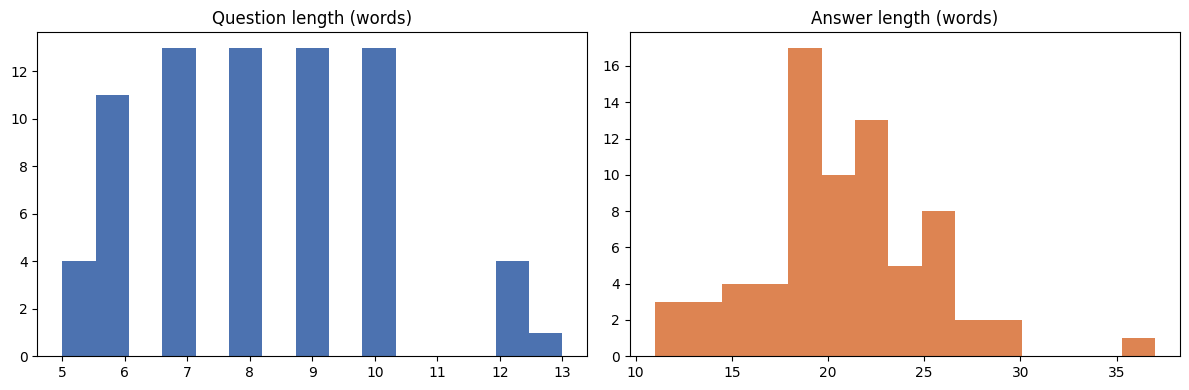

           q_len      a_len
count  72.000000  72.000000
mean    8.180556  20.736111
std     1.856290   4.402282
min     5.000000  11.000000
25%     7.000000  18.000000
50%     8.000000  21.000000
75%     9.250000  23.250000
max    13.000000  37.000000


In [ ]:
import matplotlib.pyplot as plt

qa_df['q_len'] = qa_df['question'].str.split().apply(len)
qa_df['a_len'] = qa_df['answer'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(qa_df['q_len'], bins=15, color='#4C72B0')
axes[0].set_title('Question length (words)')
axes[1].hist(qa_df['a_len'], bins=15, color='#DD8452')
axes[1].set_title('Answer length (words)')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'qa_length_distribution.png'), dpi=150)
plt.show()

print(qa_df[['q_len','a_len']].describe())


## 4. Preprocessing — Format for Causal Language Modeling
`train.csv` and `val.csv` are written directly into `PROJECT_DIR` (Drive), so they
survive a session restart.

In [ ]:
def format_example(row):
    return f"Q: {row['question']}\nA: {row['answer']}<|endoftext|>"

qa_df['text'] = qa_df.apply(format_example, axis=1)

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(qa_df, test_size=0.15, random_state=42)
print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}")

TRAIN_CSV = os.path.join(PROJECT_DIR, 'train.csv')
VAL_CSV = os.path.join(PROJECT_DIR, 'val.csv')
train_df[['text']].to_csv(TRAIN_CSV, index=False)
val_df[['text']].to_csv(VAL_CSV, index=False)

assert os.path.exists(TRAIN_CSV) and os.path.exists(VAL_CSV), "train.csv/val.csv were not written correctly."
print("Saved:", TRAIN_CSV)
print("Saved:", VAL_CSV)


Train size: 61, Validation size: 11
Saved: /content/drive/MyDrive/tourism_bot_project/train.csv
Saved: /content/drive/MyDrive/tourism_bot_project/val.csv


## 5. Load Pretrained Model & Tokenizer (DistilGPT2)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("Using device:", device)
if device == "cpu":
    print("No GPU detected -- training will still work, just a bit slower (dataset is tiny, so this is fine).")


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Using device: cuda


## 6. Tokenize the Dataset

In [ ]:
from datasets import load_dataset

# Safety check before loading -- gives a clear, actionable error instead of a cryptic one.
assert os.path.exists(TRAIN_CSV), f"{TRAIN_CSV} not found -- re-run Section 4 (Preprocessing) first."
assert os.path.exists(VAL_CSV), f"{VAL_CSV} not found -- re-run Section 4 (Preprocessing) first."

data_files = {"train": TRAIN_CSV, "validation": VAL_CSV}
raw_datasets = load_dataset("csv", data_files=data_files)

MAX_LEN = 128

def tokenize_fn(examples):
    out = tokenizer(examples['text'], truncation=True, padding='max_length', max_length=MAX_LEN)
    out['labels'] = out['input_ids'].copy()
    return out

tokenized_datasets = raw_datasets.map(tokenize_fn, batched=True, remove_columns=['text'])
tokenized_datasets


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/61 [00:00<?, ? examples/s]

Map:   0%|          | 0/11 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 61
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 11
    })
})

## 7. Fine-Tuning (25 Epochs)
Uses the Hugging Face `Trainer` API. Checkpoints are saved directly to Drive
(`PROJECT_DIR/checkpoints`) so training progress is not lost if the session drops.

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
import inspect

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Version-safe: works whether this transformers version calls it 'eval_strategy'
# or 'evaluation_strategy', and only passes 'overwrite_output_dir' if supported.
ta_params = inspect.signature(TrainingArguments.__init__).parameters
eval_key = "eval_strategy" if "eval_strategy" in ta_params else "evaluation_strategy"

ta_kwargs = dict(
    output_dir=os.path.join(PROJECT_DIR, "checkpoints"),
    num_train_epochs=25,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=5e-5,
    weight_decay=0.01,
    report_to="none",
    load_best_model_at_end=True,
    save_total_limit=2,   # avoid filling up Drive with too many checkpoints
)
ta_kwargs[eval_key] = "epoch"
if "overwrite_output_dir" in ta_params:
    ta_kwargs["overwrite_output_dir"] = True

training_args = TrainingArguments(**ta_kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
)

train_result = trainer.train()
print("\nTraining complete.")


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.426736,2.824592
2,2.656688,2.598703
3,2.126808,2.540136
4,1.841302,2.570879
5,1.588668,2.587624
6,1.398790,2.715310
7,1.144543,2.781033
8,1.065684,2.850201
9,0.933973,2.900704
10,0.840080,3.031759


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].



Training complete.


## 8. Evaluation Metrics & Loss Curves

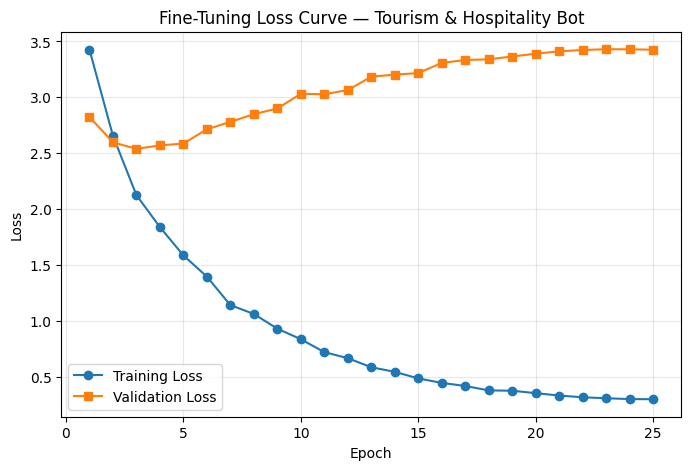

In [ ]:
log_history = trainer.state.log_history
train_loss = [(e['epoch'], e['loss']) for e in log_history if 'loss' in e]
eval_loss = [(e['epoch'], e['eval_loss']) for e in log_history if 'eval_loss' in e]

train_epochs, train_vals = zip(*train_loss)
eval_epochs, eval_vals = zip(*eval_loss)

plt.figure(figsize=(8,5))
plt.plot(train_epochs, train_vals, label='Training Loss', marker='o')
plt.plot(eval_epochs, eval_vals, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-Tuning Loss Curve — Tourism & Hospitality Bot')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(os.path.join(PROJECT_DIR, 'training_loss_curve.png'), dpi=150)
plt.show()


In [ ]:
import math

final_eval_loss = eval_vals[-1]
perplexity = math.exp(final_eval_loss)
print(f"Final Validation Loss: {final_eval_loss:.4f}")
print(f"Perplexity: {perplexity:.2f}")
# Lower perplexity = the model is less 'surprised' by the validation text,
# i.e. it has learned the Q&A patterns well.


Final Validation Loss: 3.4259
Perplexity: 30.75


## 9. Test the Bot — Sample Conversations

In [ ]:
def ask_bot(question, max_new_tokens=60):
    prompt = f"Q: {question}\nA:"
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    output = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        top_p=0.92,
        temperature=0.7,
        pad_token_id=tokenizer.eos_token_id,
    )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    answer = text.split("A:")[-1].strip()
    return answer

test_questions = [
    "What is your cancellation policy?",
    "Do you offer airport transfer service?",
    "What meal plans do you offer?",
    "Can I bring pets to the hotel?",
    "How do I request early check-in?",
]

for q in test_questions:
    print(f"Q: {q}")
    print(f"A: {ask_bot(q)}")
    print("-" * 60)


Q: What is your cancellation policy?
A: Cancellations are subject to an individual's specific cancellation policy. Cancellations are subject to an individual's specific cancellation policy. Cancellations are subject to an individual's specific cancellation policy. Cancellations are subject to an individual's specific cancellation policy. Cancellations are subject to an individual
------------------------------------------------------------
Q: Do you offer airport transfer service?
A: Yes, airport transfer is free and is
------------------------------------------------------------
Q: What meal plans do you offer?
A: We offer free lunches, breakfast and dinner; free lunches are provided during our stay, and we will offer additional meals for our guests
------------------------------------------------------------
Q: Can I bring pets to the hotel?
A: 
------------------------------------------------------------
Q: How do I request early check-in?
A: You can request early check-in at checko

## 10. Save the Fine-Tuned Model (to Drive)

In [ ]:
MODEL_DIR = os.path.join(PROJECT_DIR, "tourism_bot_final")
model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print("Model saved to:", MODEL_DIR)
print("Because this is inside Drive, it will still be there even after the session ends.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/tourism_bot_project/tourism_bot_final
Because this is inside Drive, it will still be there even after the session ends.


---
## 11. Interactive Demo with Gradio (for your presentation video)

**IMPORTANT — run this cell separately, by itself, when you're ready to record.**
`demo.launch()` keeps running to keep the chat UI live — this is expected behavior,
NOT a crash or a hang. To stop it, click the stop button on the cell (or
`Runtime -> Interrupt execution`).

In [ ]:
import gradio as gr

def gradio_chat(question, history):
    return ask_bot(question)

demo = gr.ChatInterface(
    fn=gradio_chat,
    title="Tourism & Hospitality Assistant",
    description="Ask about bookings, cancellations, meal plans, and hotel policies.",
    examples=[
        "What is your cancellation policy?",
        "Do you offer airport transfer service?",
        "What meal plans do you offer?",
    ],
)
demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a20d39dc94ae4d1f6f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 12. Supporting Industry EDA — Hotel Bookings Dataset

In [ ]:
import seaborn as sns

hotels = pd.read_csv(os.path.join(PROJECT_DIR, 'Hotel_Bookings.csv'))
hotels['country'] = hotels['country'].fillna(hotels['country'].mode()[0])
hotels[['children','agent','company']] = hotels[['children','agent','company']].fillna(0)
print(hotels.shape)


(119390, 32)


### 12.1 Correlation Heatmap

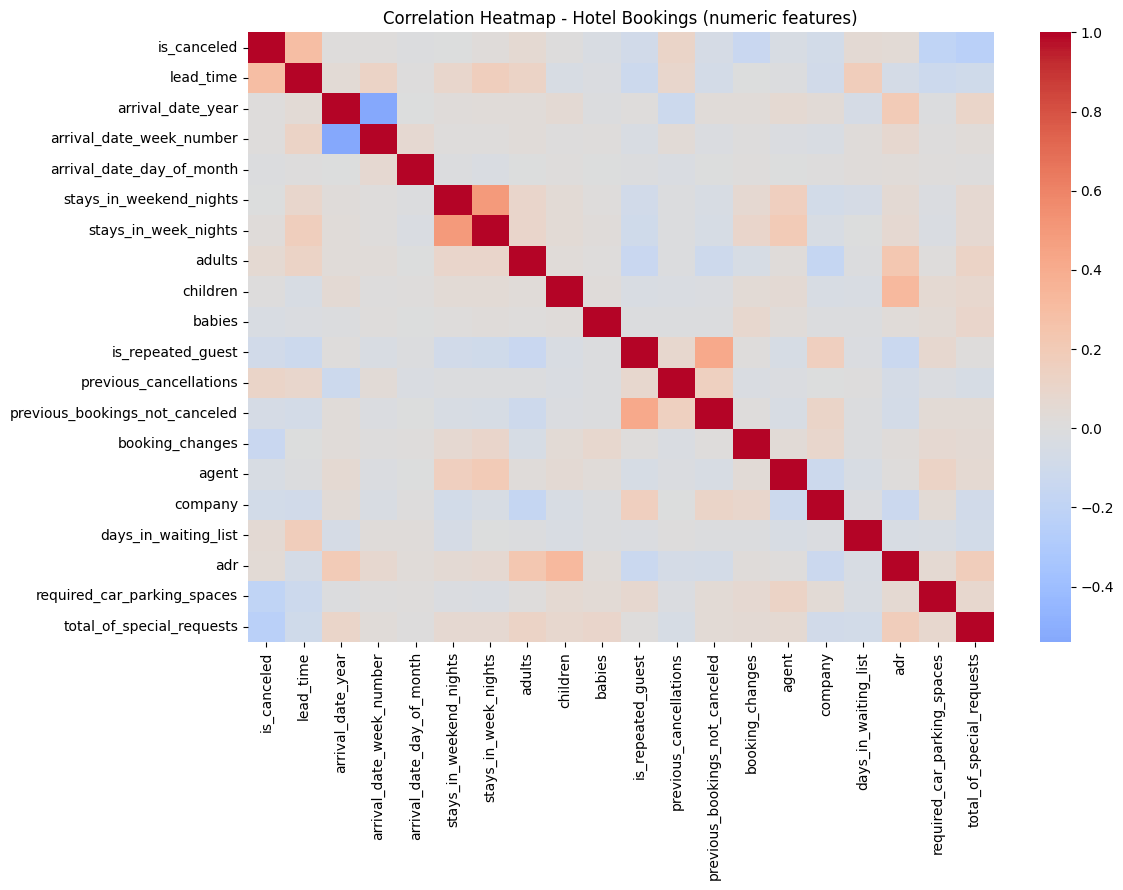

In [ ]:
numeric_cols = hotels.select_dtypes(include='number').columns
plt.figure(figsize=(12,9))
sns.heatmap(hotels[numeric_cols].corr(), cmap='coolwarm', annot=False, center=0)
plt.title('Correlation Heatmap - Hotel Bookings (numeric features)')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'correlation_heatmap.png'), dpi=150)
plt.show()


### 12.2 ADR vs Lead Time

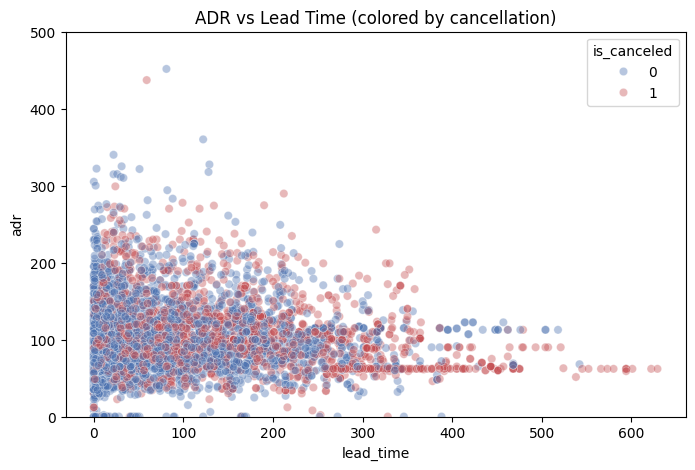

In [ ]:
sample = hotels.sample(5000, random_state=42)
plt.figure(figsize=(8,5))
sns.scatterplot(data=sample, x='lead_time', y='adr', hue='is_canceled', alpha=0.4, palette=['#4C72B0','#C44E52'])
plt.title('ADR vs Lead Time (colored by cancellation)')
plt.ylim(0, 500)
plt.savefig(os.path.join(PROJECT_DIR, 'adr_vs_leadtime.png'), dpi=150)
plt.show()


### 12.3 Cancellation Rate by Lead-Time Bucket

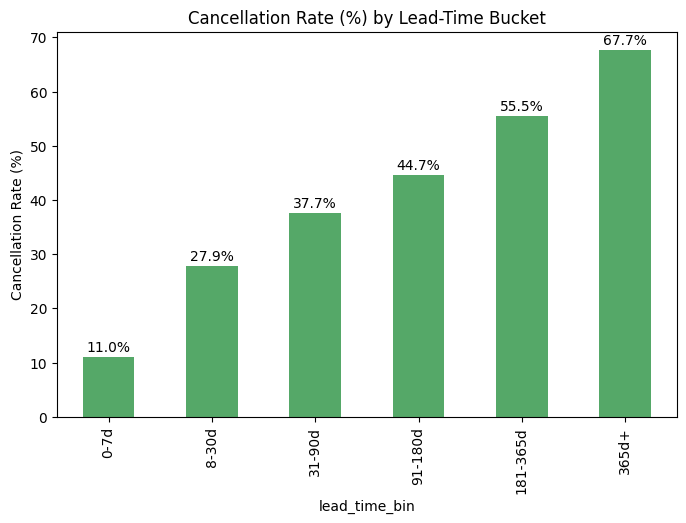

lead_time_bin
0-7d        10.984255
8-30d       27.863924
31-90d      37.698372
91-180d     44.710466
181-365d    55.453955
365d+       67.662008
Name: is_canceled, dtype: float64


In [ ]:
bins = [0, 7, 30, 90, 180, 365, 1000]
labels = ['0-7d','8-30d','31-90d','91-180d','181-365d','365d+']
hotels['lead_time_bin'] = pd.cut(hotels['lead_time'], bins=bins, labels=labels)
cancel_rate = hotels.groupby('lead_time_bin', observed=True)['is_canceled'].mean() * 100

plt.figure(figsize=(8,5))
cancel_rate.plot(kind='bar', color='#55A868')
plt.title('Cancellation Rate (%) by Lead-Time Bucket')
plt.ylabel('Cancellation Rate (%)')
for i, v in enumerate(cancel_rate):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.savefig(os.path.join(PROJECT_DIR, 'cancellation_by_leadtime.png'), dpi=150)
plt.show()
print(cancel_rate)


---
## 13. Bonus: Real Tourism Destination Dataset (Kaggle) — EDA + Recommendation System
Uses the **Indonesia Tourism Destination dataset** (Kaggle: `aprabowo/indonesia-tourism-destination`) —
437 destinations, 300 users, 10,000 ratings, and curated packages.

In [ ]:
tourism_places = pd.read_csv(os.path.join(PROJECT_DIR, 'tourism_with_id.csv'))
tourism_places = tourism_places.drop(columns=[c for c in tourism_places.columns if 'Unnamed' in c])
tourism_users = pd.read_csv(os.path.join(PROJECT_DIR, 'user.csv'))
tourism_ratings = pd.read_csv(os.path.join(PROJECT_DIR, 'tourism_rating.csv'))
tourism_packages = pd.read_csv(os.path.join(PROJECT_DIR, 'package_tourism.csv'))

print("Places:", tourism_places.shape, "| Users:", tourism_users.shape,
      "| Ratings:", tourism_ratings.shape, "| Packages:", tourism_packages.shape)
tourism_places.head()


Places: (437, 11) | Users: (300, 3) | Ratings: (10000, 3) | Packages: (100, 7)


,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134


### 13.1 Category & City Distribution

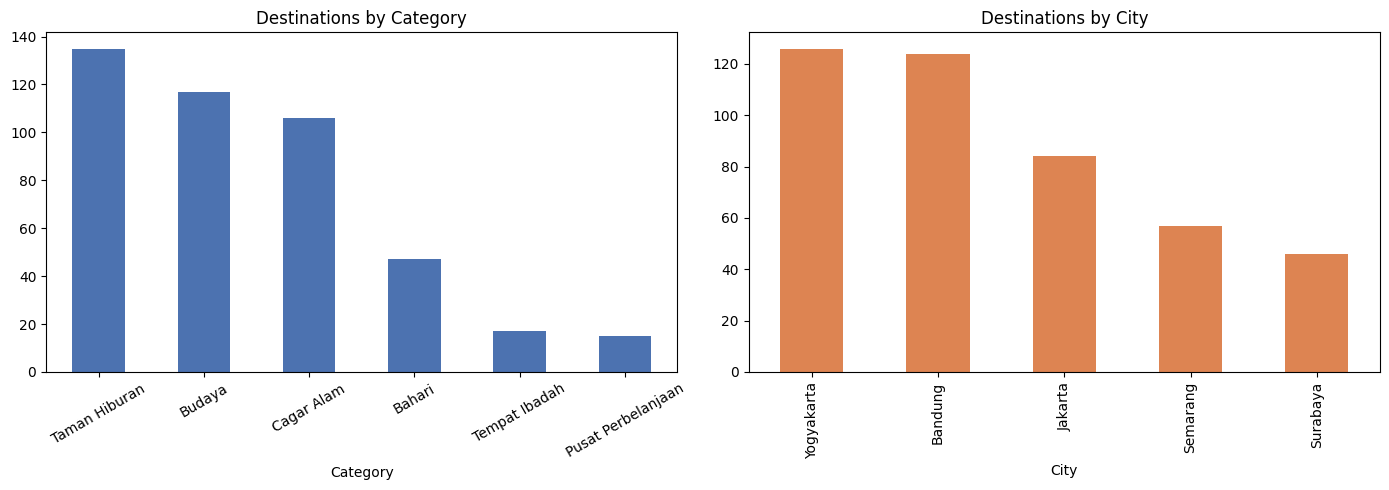

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
tourism_places['Category'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Destinations by Category')
axes[0].tick_params(axis='x', rotation=30)

tourism_places['City'].value_counts().plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Destinations by City')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'tourism_category_city_distribution.png'), dpi=150)
plt.show()


### 13.2 Price vs. Rating

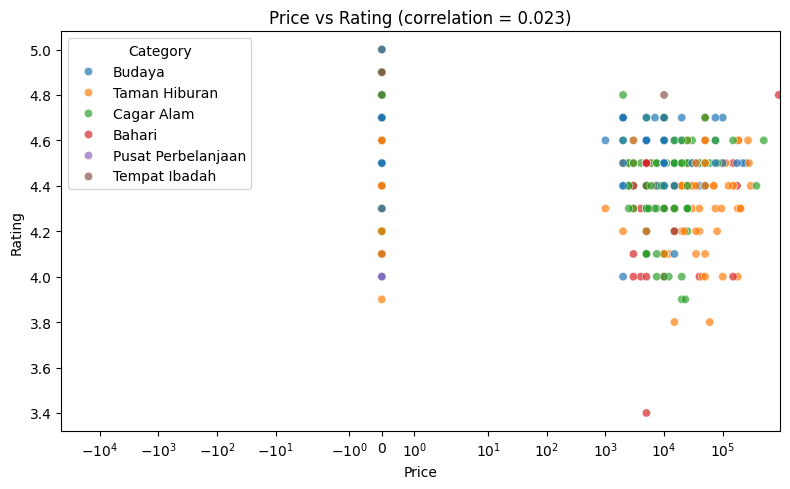

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=tourism_places, x='Price', y='Rating', hue='Category', alpha=0.7)
plt.xscale('symlog')
plt.title(f'Price vs Rating (correlation = {tourism_places["Price"].corr(tourism_places["Rating"]):.3f})')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'tourism_price_vs_rating.png'), dpi=150)
plt.show()


### 13.3 Average User Rating by Category

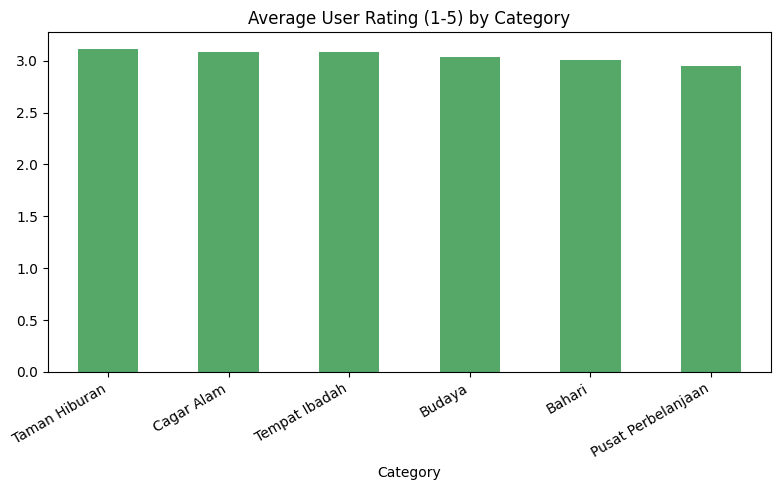

Category
Taman Hiburan         3.117917
Cagar Alam            3.080745
Tempat Ibadah         3.080519
Budaya                3.034663
Bahari                3.006487
Pusat Perbelanjaan    2.945455
Name: Place_Ratings, dtype: float64


In [ ]:
merged = tourism_ratings.merge(tourism_places[['Place_Id','Category']], on='Place_Id')
avg_by_cat = merged.groupby('Category')['Place_Ratings'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_by_cat.plot(kind='bar', color='#55A868')
plt.title('Average User Rating (1-5) by Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'tourism_avg_rating_by_category.png'), dpi=150)
plt.show()
print(avg_by_cat)


### 13.4 Content-Based Recommendation System

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tourism_places['combined_features'] = (
    tourism_places['Category'] + " " + tourism_places['City'] + " " + tourism_places['Description'].fillna('')
)

tfidf = TfidfVectorizer(stop_words='english', max_features=2000)
tfidf_matrix = tfidf.fit_transform(tourism_places['combined_features'])
sim_matrix = cosine_similarity(tfidf_matrix)

def recommend_similar_places(place_name, top_n=5):
    idx = tourism_places[tourism_places['Place_Name'] == place_name].index
    if len(idx) == 0:
        return f"Place '{place_name}' not found in the dataset."
    idx = idx[0]
    scores = sorted(list(enumerate(sim_matrix[idx])), key=lambda x: x[1], reverse=True)[1:top_n+1]
    return tourism_places.iloc[[s[0] for s in scores]][['Place_Name','City','Category','Rating']]

recommend_similar_places('Monumen Nasional')


,Place_Name,City,Category,Rating
258,Monumen Perjuangan Rakyat Jawa Barat,Bandung,Budaya,4.5
43,Monumen Selamat Datang,Jakarta,Budaya,4.7
256,Monumen Bandung Lautan Api,Bandung,Budaya,4.3
380,Tugu Muda Semarang,Semarang,Budaya,4.7
427,Monumen Bambu Runcing Surabaya,Surabaya,Budaya,4.6


---
## Notes for the Research Paper
- Use `training_loss_curve.png` (in your Drive `PROJECT_DIR`) in the **Results** section.
- Use `correlation_heatmap.png`, `adr_vs_leadtime.png`, `cancellation_by_leadtime.png`,
  `tourism_category_city_distribution.png`, `tourism_price_vs_rating.png`, and
  `tourism_avg_rating_by_category.png` in **Industry Analysis / Results**.
- Report the final validation loss and perplexity (Section 8) in your **Results** table.
- All generated files are saved permanently in: `/content/drive/MyDrive/tourism_bot_project/`